# KV Cache Benchmark Visualization

This notebook loads `benchmark_results.csv` and generates easy-to-read charts comparing generation with and without KV cache.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    from benchmarking.config import BENCHMARK_RESULTS_CSV_PATH
except ModuleNotFoundError:
    from config import BENCHMARK_RESULTS_CSV_PATH

plt.style.use('ggplot')

CSV_PATH = Path(BENCHMARK_RESULTS_CSV_PATH)
if not CSV_PATH.exists():
    raise FileNotFoundError(f'Could not find {CSV_PATH.resolve()}')

df = pd.read_csv(CSV_PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], errors='coerce')
df['execution_device'] = df['execution_device'].astype(str)
df['mode'] = df['mode'].astype(str)

numeric_cols = [
    'prompt_tokens', 'new_tokens', 'total_tokens_processed', 'avg_seconds',
    'tokens_per_second', 'speedup_vs_no_cache', 'block_size', 'total_blocks'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Rows:', len(df))
print('Modes:', sorted(df['mode'].dropna().unique().tolist()))
print('Devices:', sorted(df['execution_device'].dropna().unique().tolist()))
display(df.head(5))

Rows: 68
Modes: ['kv_cache', 'no_kv_cache']
Devices: ['cpu']


,timestamp_utc,benchmark_label,execution_device,cuda_available,mode,prompt,prompt_tokens,new_tokens,total_tokens_processed,total_blocks,...,warmup_runs,timed_runs,avg_seconds,stdev_seconds,min_seconds,max_seconds,median_seconds,tokens_per_second,speedup_vs_no_cache,run_durations_json
0,2026-04-12 05:06:07.421679+00:00,kv_cache_vs_no_kv_cache,cpu,False,kv_cache,Hi,1,50,51,128,...,1,1,0.803780,0.0,0.803780,0.803780,0.803780,62.206084,1.523134,[0.8037799000740051]
1,2026-04-12 05:06:07.421679+00:00,kv_cache_vs_no_kv_cache,cpu,False,no_kv_cache,Hi,1,50,51,128,...,1,1,1.224265,0.0,1.224265,1.224265,1.224265,40.840841,1.000000,[1.2242646999657154]
2,2026-04-12 05:06:17.195082+00:00,kv_cache_vs_no_kv_cache,cpu,False,kv_cache,Hi there,2,75,77,128,...,1,1,1.235915,0.0,1.235915,1.235915,1.235915,60.683805,3.363865,[1.2359146000817418]
3,2026-04-12 05:06:17.195082+00:00,kv_cache_vs_no_kv_cache,cpu,False,no_kv_cache,Hi there,2,75,77,128,...,1,1,4.157450,0.0,4.157450,4.157450,4.157450,18.039906,1.000000,[4.1574495998211205]
4,2026-04-12 05:06:35.233923+00:00,kv_cache_vs_no_kv_cache,cpu,False,kv_cache,The quick brown fox,4,100,104,128,...,1,1,2.301700,0.0,2.301700,2.301700,2.301700,43.446139,2.729962,[2.3017004998400807]


In [2]:
# Build paired trial table (one row per timestamp/prompt/new_tokens config)
pair_keys = ['timestamp_utc', 'prompt', 'new_tokens', 'prompt_tokens', 'block_size', 'total_blocks', 'execution_device']

kv = (
    df[df['mode'] == 'kv_cache'][pair_keys + ['avg_seconds', 'tokens_per_second', 'speedup_vs_no_cache']]
    .rename(columns={
        'avg_seconds': 'kv_avg_seconds',
        'tokens_per_second': 'kv_tokens_per_second',
        'speedup_vs_no_cache': 'kv_reported_speedup'
    })
)

no_kv = (
    df[df['mode'] == 'no_kv_cache'][pair_keys + ['avg_seconds', 'tokens_per_second']]
    .rename(columns={
        'avg_seconds': 'no_kv_avg_seconds',
        'tokens_per_second': 'no_kv_tokens_per_second'
    })
)

paired = pd.merge(kv, no_kv, on=pair_keys, how='inner')
paired['computed_speedup'] = paired['no_kv_avg_seconds'] / paired['kv_avg_seconds']
paired = paired.sort_values(['new_tokens', 'prompt_tokens']).reset_index(drop=True)

print('Paired trials:', len(paired))
display(paired.head(10))

Paired trials: 34


,timestamp_utc,prompt,new_tokens,prompt_tokens,block_size,total_blocks,execution_device,kv_avg_seconds,kv_tokens_per_second,kv_reported_speedup,no_kv_avg_seconds,no_kv_tokens_per_second,computed_speedup
0,2026-04-13 16:59:16.974572+00:00,Refactor test,30,3,16,128,cpu,1.848384,16.230390,1.677939,3.101477,9.672810,1.677939
1,2026-04-13 17:01:05.017926+00:00,Final verification,40,2,16,32,cpu,2.857246,13.999493,1.566017,4.474496,8.939554,1.566017
2,2026-04-12 05:06:07.421679+00:00,Hi,50,1,16,128,cpu,0.803780,62.206084,1.523134,1.224265,40.840841,1.523134
3,2026-04-12 05:13:43.146918+00:00,AI,50,1,16,128,cpu,1.990429,25.120218,1.809280,3.601243,13.884096,1.809280
4,2026-04-13 17:00:25.595045+00:00,Checking refactor,50,4,8,128,cpu,3.644716,13.718489,1.631173,5.945164,8.410198,1.631173
5,2026-04-12 05:17:29.455393+00:00,One two three,60,3,4,128,cpu,2.938324,20.419802,1.904870,5.597125,10.719790,1.904870
6,2026-04-12 05:06:17.195082+00:00,Hi there,75,2,16,128,cpu,1.235915,60.683805,3.363865,4.157450,18.039906,3.363865
7,2026-04-12 05:15:13.359799+00:00,The future of,80,3,8,128,cpu,4.492553,17.807247,2.626936,11.801651,6.778713,2.626936
8,2026-04-12 05:06:35.233923+00:00,The quick brown fox,100,4,16,128,cpu,2.301700,43.446139,2.729962,6.283556,15.914556,2.729962
9,2026-04-12 05:16:38.776159+00:00,A long time ago,100,4,16,64,cpu,4.363166,22.919137,3.567141,15.564029,6.425072,3.567141


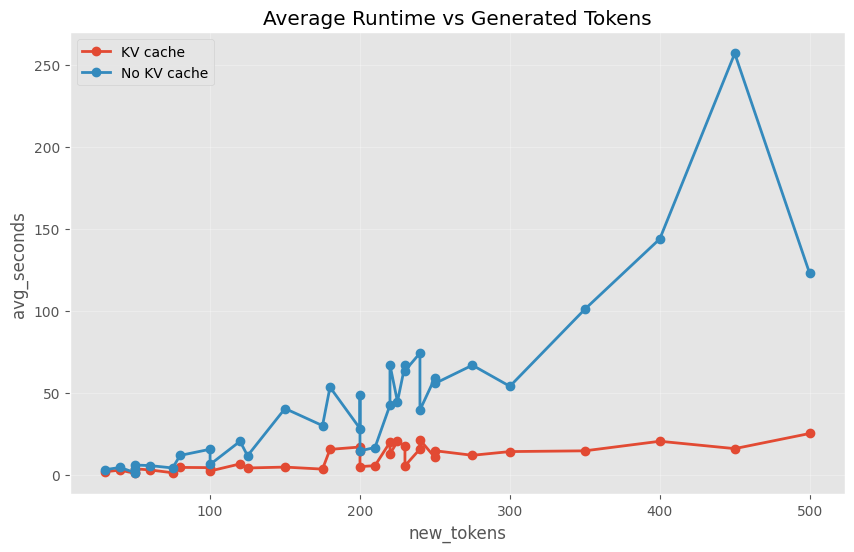

In [3]:
# Chart 1: runtime vs generated tokens (both modes)
fig, ax = plt.subplots(figsize=(10, 6))
for mode, label in [('kv_cache', 'KV cache'), ('no_kv_cache', 'No KV cache')]:
    view = df[df['mode'] == mode].sort_values('new_tokens')
    ax.plot(view['new_tokens'], view['avg_seconds'], marker='o', linewidth=2, label=label)

ax.set_title('Average Runtime vs Generated Tokens')
ax.set_xlabel('new_tokens')
ax.set_ylabel('avg_seconds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

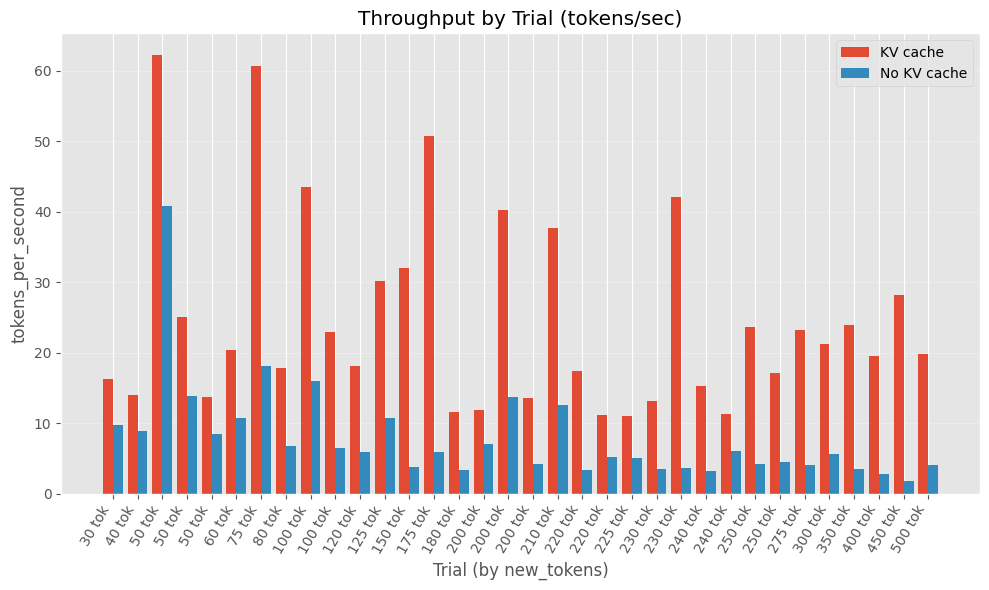

In [4]:
# Chart 2: throughput comparison (tokens/sec)
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(paired))
ax.bar([i - 0.2 for i in x], paired['kv_tokens_per_second'], width=0.4, label='KV cache')
ax.bar([i + 0.2 for i in x], paired['no_kv_tokens_per_second'], width=0.4, label='No KV cache')

labels = [f"{int(n)} tok" for n in paired['new_tokens']]
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=60, ha='right')
ax.set_title('Throughput by Trial (tokens/sec)')
ax.set_xlabel('Trial (by new_tokens)')
ax.set_ylabel('tokens_per_second')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

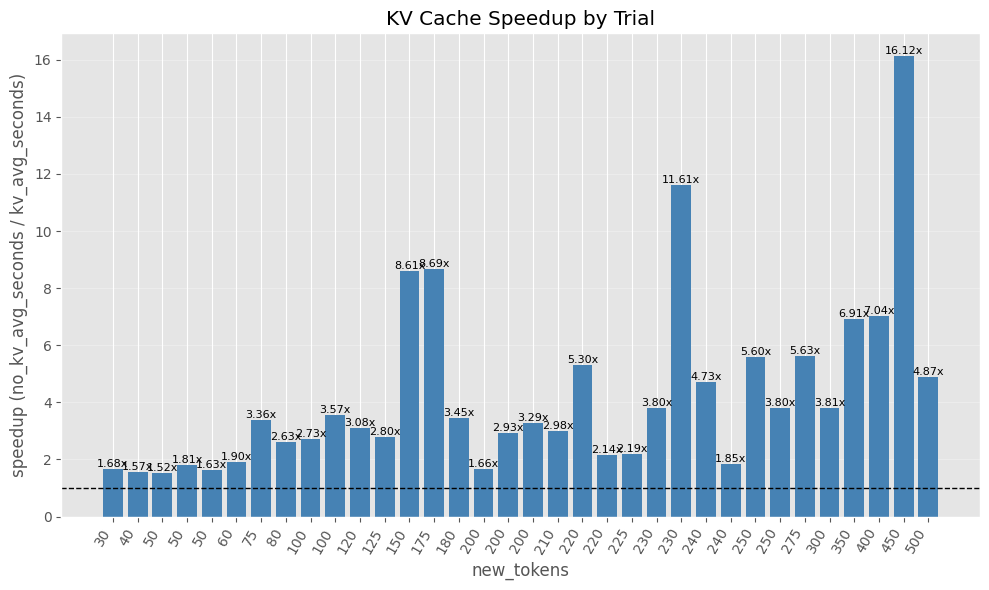

{'trials': 34,
 'device': 'cpu',
 'avg_speedup_x': 4.273667505557958,
 'median_speedup_x': 3.326152908726889,
 'min_speedup_x': 1.5231342558491394,
 'max_speedup_x': 16.117993118106536}

In [5]:
# Chart 3: speedup and summary
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(paired)), paired['computed_speedup'], color='steelblue')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(range(len(paired)))
ax.set_xticklabels([f"{int(n)}" for n in paired['new_tokens']], rotation=60, ha='right')
ax.set_title('KV Cache Speedup by Trial')
ax.set_xlabel('new_tokens')
ax.set_ylabel('speedup (no_kv_avg_seconds / kv_avg_seconds)')
ax.grid(True, axis='y', alpha=0.3)

for i, b in enumerate(bars):
    value = paired['computed_speedup'].iloc[i]
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{value:.2f}x", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

summary = {
    'trials': int(len(paired)),
    'device': paired['execution_device'].mode().iloc[0] if len(paired) else 'unknown',
    'avg_speedup_x': float(paired['computed_speedup'].mean()) if len(paired) else float('nan'),
    'median_speedup_x': float(paired['computed_speedup'].median()) if len(paired) else float('nan'),
    'min_speedup_x': float(paired['computed_speedup'].min()) if len(paired) else float('nan'),
    'max_speedup_x': float(paired['computed_speedup'].max()) if len(paired) else float('nan'),
}
summary